### Cleaning and Exploring LC Loan Data

Setting up the Loan Dataset

In [66]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import plotly.express as px

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import cross_val_score
import csv

import xgboost as xgb

In [ ]:
# Reading the main dataset on LC Loans from Kaggle
# The dataset is available at https://www.kaggle.com/datasets/wordsforthewise/lending-club
df = pd.read_csv('C:\Projects\loan.csv')
df.head(5)

In [ ]:
# Keeping only the columns that are relevant for our analysis  
columns_to_keep = ['loan_amnt', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose']
loan_df = df[columns_to_keep]

# Calculating loan amount as a percentage of income
loan_df['loan_percent_income'] = loan_df['loan_amnt'] / loan_df['annual_inc']

# Renaming columns for better readability
loan_df.columns = ['loan_amnt', 'loan_int_rate', 'installment', 'loan_grade', 'person_emp_length', 
                   'person_home_ownership', 'person_income', 'loan_status', 'loan_intent', 'loan_percent_income']

# Creating a new column for age based on random values
loan_df['person_age'] = np.random.randint(18, 110, loan_df.shape[0])

# Covertig the loan status to a binary variable
loan_df['loan_status'] = loan_df['loan_status'].map({'Current': 1,'Fully Paid': 1, 'Late (31-120 days)' : 0, 
                                                     'Charged Off': 0, 'In Grace Period': 0, 'Does not meet the credit policy. Status:Fully Paid': 1, 
                                                     'Does not meet the credit policy. Status:Charged Off': 0, 'Default': 0})

loan_df.dropna(subset=['loan_status', 'loan_int_rate', 'person_emp_length', 'person_income'], inplace=True)

loan_df['cb_person_cred_hist_length'] = np.random.randint(0, 30, loan_df.shape[0])

# Extracting the number of years from the employment length column
loan_df['person_emp_length'] = loan_df['person_emp_length'].str.extract(r'(\d+)')
loan_df.dropna(subset=['person_emp_length'], inplace=True)
loan_df['person_emp_length'] = loan_df['person_emp_length'].astype(int)

# Use Pandas to drop the record from the data frame and create a new one
loan_df_new = loan_df.drop(loan_df[loan_df['person_income'] > 6*10**8].index)

loan_df_new

In [ ]:
num_rows = loan_df['loan_status'].shape[0]
print(f"Number of rows in y_train: {num_rows}")

Number of rows in y_train: 2110451


### Exploring Data

In [6]:
# Checking the structure of the data
print(loan_df.dtypes)

# Checking the first five rows of the data
print(loan_df.head(5))

loan_amnt                       int64
loan_int_rate                 float64
installment                   float64
loan_grade                     object
person_emp_length               int64
person_home_ownership          object
person_income                 float64
loan_status                   float64
loan_intent                    object
loan_percent_income           float64
person_age                      int32
cb_person_cred_hist_length      int32
dtype: object
   loan_amnt  loan_int_rate  installment loan_grade  person_emp_length  \
0       2500          13.56        84.92          C                 10   
1      30000          18.94       777.23          D                 10   
2       5000          17.97       180.69          D                  6   
3       4000          18.94       146.51          D                 10   
4      30000          16.14       731.78          C                 10   

  person_home_ownership  person_income  loan_status         loan_intent  \
0         

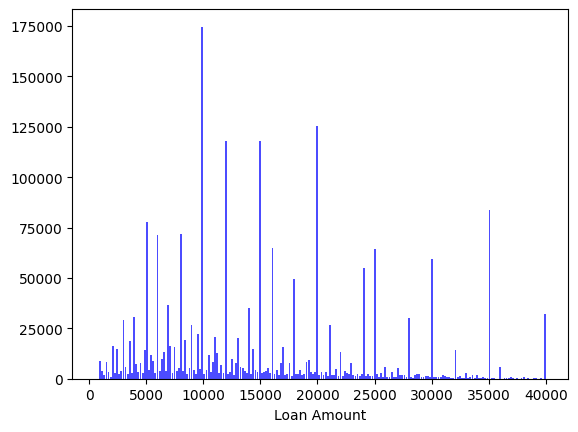

In [7]:
# Looking at the distribution of loan amounts with a histogram
n, bins, patches = plt.hist(x=loan_df['loan_amnt'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

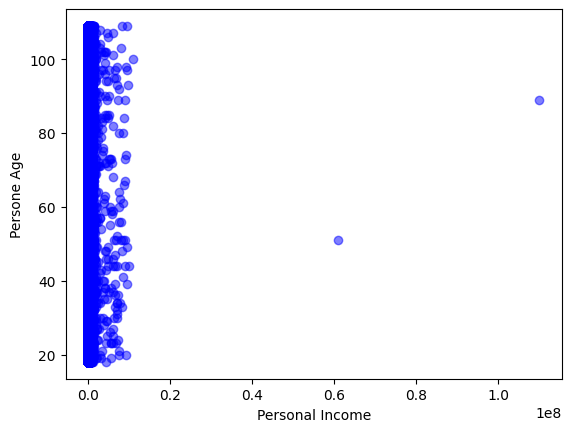

In [8]:
# Plotting a scatter plot of income against age
plt.scatter(loan_df['person_income'], loan_df['person_age'],c='blue', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Persone Age')
plt.show()

In [9]:
# Creating a cross table of the loan intent and loan status
print(pd.crosstab(loan_df['loan_intent'], loan_df['loan_status'], margins = True))

loan_status            0.0      1.0      All
loan_intent                                 
car                   2162    20260    22422
credit_card          49810   433569   483379
debt_consolidation  166195  1030325  1196520
educational             84      331      415
home_improvement     15598   122656   138254
house                 1667    11432    13099
major_purchase        5675    41561    47236
medical               3295    21527    24822
moving                2211    12117    14328
other                16598   111559   128157
renewable_energy       223     1124     1347
small_business        4855    19071    23926
vacation              1722    12501    14223
wedding                283     2040     2323
All                 270378  1840073  2110451


In [10]:
# Creating a cross table for home ownership and loan status and loan grade
print(pd.crosstab(loan_df['person_home_ownership'], [loan_df['loan_status'], loan_df['loan_grade']]))

loan_status             0.0                                             1.0  \
loan_grade                A      B      C      D      E     F     G       A   
person_home_ownership                                                         
ANY                       2     14     17     13     12     3     2     190   
MORTGAGE               7095  23475  37086  25550  15406  6069  1937  221357   
NONE                      0      4      1      1      0     1     0       6   
OTHER                     2     12      7      7      5     2     3      24   
OWN                    1571   5580   9079   6332   3736  1505   515   41015   
RENT                   5560  23803  40641  29473  16871  6813  2173  128873   

loan_status                                                        
loan_grade                  B       C       D      E      F     G  
person_home_ownership                                              
ANY                       267     199      87     27      6     4  
MORTGAGE        

In [11]:
# Creating a cross table of home ownership, loan status, and average percent income
print(pd.crosstab(loan_df['person_home_ownership'], loan_df['loan_status'],
              values=loan_df['loan_percent_income'], aggfunc='mean'))

loan_status                 0.0       1.0
person_home_ownership                    
ANY                    0.195234  0.213482
MORTGAGE                    inf       inf
NONE                   0.247913  0.279989
OTHER                  0.233355  0.179263
OWN                    0.249924       inf
RENT                        inf       inf


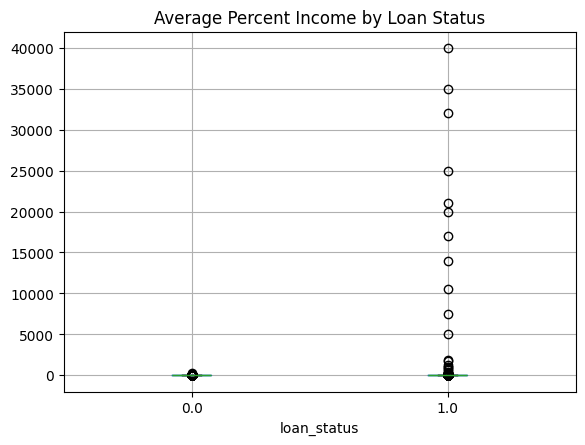

In [12]:
# Creating a box plot of percentage income by loan status
loan_df.boxplot(column = ['loan_percent_income'], by = 'loan_status')
plt.title('Average Percent Income by Loan Status')
plt.suptitle('')
plt.show()

Dealing with Outliers

In [13]:
# Creating a cross table of home ownership, loan status, and employment length
print(pd.crosstab(loan_df['loan_status'], loan_df['person_home_ownership'],
                  values=loan_df['person_emp_length'], aggfunc=['min', 'max']))

                      min                              max                \
person_home_ownership ANY MORTGAGE NONE OTHER OWN RENT ANY MORTGAGE NONE   
loan_status                                                                
0.0                     1        1    1     1   1    1  10       10   10   
1.0                     1        1    1     1   1    1  10       10   10   

                                      
person_home_ownership OTHER OWN RENT  
loan_status                           
0.0                      10  10   10  
1.0                      10  10   10  


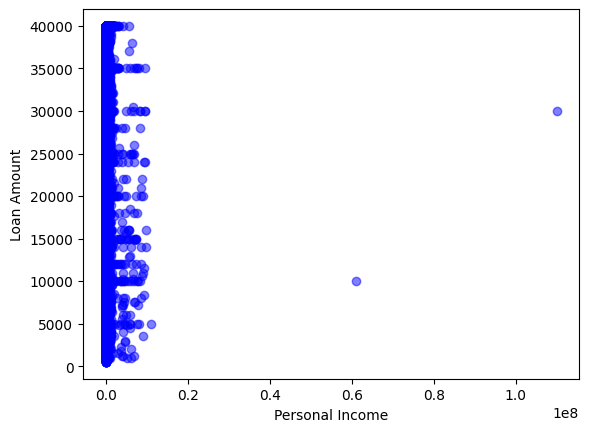

In [14]:
# Creating the scatter plot for income and loan amount
plt.scatter(loan_df['person_income'], loan_df['loan_amnt'], c='blue', alpha=0.5)
plt.xlabel("Personal Income")
plt.ylabel("Loan Amount")
plt.show()

In [15]:
# Use Pandas to drop the record from the data frame and create a new one
#loan_df_new = loan_df.drop(loan_df[loan_df['person_income'] > 6*10**8].index)

### Logistic Regression

In [16]:
# Creating the X and y data sets
X = loan_df_new[['loan_int_rate']]
y = loan_df_new[['loan_status']]

# Creating and fittin a logistic regression model
clf_logistic_single = LogisticRegression(solver='lbfgs')
clf_logistic_single.fit(X, np.ravel(y))

# Printing the parameters of the model
print(clf_logistic_single.get_params())

# Printing the intercept of the model
print(clf_logistic_single.intercept_)

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
[3.58498351]


Multivariate Logistic Regression

In [17]:
# Creating X data for the model
X_multi = loan_df_new[['loan_int_rate','person_emp_length']]

# Creating a set of y data for training
y = loan_df_new[['loan_status']]

# Creating and train a new logistic regression
clf_logistic_multi = LogisticRegression(solver='lbfgs').fit(X_multi, np.ravel(y))

# Printing the intercept of the model
print(clf_logistic_multi.intercept_)

[3.54409743]


Creating Training and Testing Datasets

In [18]:
# Create the X and y data sets
X = loan_df_new[['loan_int_rate','person_emp_length','person_income']]
y = loan_df_new[['loan_status']]

# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)

# Create and fit the logistic regression model
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Print the models coefficients
print(clf_logistic.coef_)

[[-1.16365246e-01  5.15819967e-03  1.74503321e-06]]


In [19]:
num_rows = y_train.shape[0]
print(f"Number of rows in y_train: {num_rows}")

Number of rows in y_train: 1266270


Getting Dummies for Non-Numeric Data : Loan Grade, Home Ownership, Loan Intent

In [ ]:
# Create two data sets for numeric and non-numeric data
cred_num = loan_df_new.select_dtypes(exclude=['object'])
cred_str = loan_df_new.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
cred_str_onehot = pd.get_dummies(cred_str)

# Union the one-hot encoded columns to the numeric ones
cr_loan_prep = pd.concat([cred_num, cred_str_onehot], axis=1)

# Print the columns in the new data set
print(cr_loan_prep.columns)

cr_loan_prep.replace({False: 0, True: 1}, inplace=True)
bL
cr_loan_prep.head(5)


Index(['loan_amnt', 'loan_int_rate', 'installment', 'person_emp_length',
       'person_income', 'loan_status', 'loan_percent_income', 'person_age',
       'cb_person_cred_hist_length', 'loan_grade_A', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'person_home_ownership_ANY',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_NONE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_car',
       'loan_intent_credit_card', 'loan_intent_debt_consolidation',
       'loan_intent_educational', 'loan_intent_home_improvement',
       'loan_intent_house', 'loan_intent_major_purchase',
       'loan_intent_medical', 'loan_intent_moving', 'loan_intent_other',
       'loan_intent_renewable_energy', 'loan_intent_small_business',
       'loan_intent_vacation', 'loan_intent_wedding'],
      dtype='object')


C:\Users\razor\AppData\Local\Temp\ipykernel_12720\2082211259.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr_loan_prep.replace({False: 0, True: 1}, inplace=True)


,loan_amnt,loan_int_rate,installment,person_emp_length,person_income,loan_status,loan_percent_income,person_age,cb_person_cred_hist_length,loan_grade_A,...,loan_intent_home_improvement,loan_intent_house,loan_intent_major_purchase,loan_intent_medical,loan_intent_moving,loan_intent_other,loan_intent_renewable_energy,loan_intent_small_business,loan_intent_vacation,loan_intent_wedding
0,2500,13.56,84.92,10,55000.0,1.0,0.045455,50,26,0,...,0,0,0,0,0,0,0,0,0,0
1,30000,18.94,777.23,10,90000.0,1.0,0.333333,69,1,0,...,0,0,0,0,0,0,0,0,0,0
2,5000,17.97,180.69,6,59280.0,1.0,0.084345,60,7,0,...,0,0,0,0,0,0,0,0,0,0
3,4000,18.94,146.51,10,92000.0,1.0,0.043478,107,22,0,...,0,0,0,0,0,0,0,0,0,0
4,30000,16.14,731.78,10,57250.0,1.0,0.524017,106,26,0,...,0,0,0,0,0,0,0,0,0,0


Creating Multiple Training and Testing Datasets using More Columns

In [43]:
# Create the X and y data sets
X = cr_loan_prep[['loan_int_rate','person_emp_length','person_income']]
X1 = cr_loan_prep[['loan_int_rate', 'person_emp_length', 'person_income', 
                       'person_home_ownership_OWN', 'person_home_ownership_RENT', 
                       'loan_intent_educational', 'loan_intent_home_improvement']]
# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=.4, random_state=123)

Probabilities of Default

In [44]:
# Train the logistic regression model on the training data
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Create predictions of probability for loan status using test data
preds = clf_logistic.predict_proba(X_test)

# Create dataframes of first five predictions, and first five true labels
preds_df = pd.DataFrame(preds[:,1][0:5], columns = ['prob_default'])
true_df = y_test.head(5)

# Concatenate and print the two data frames for comparison
print(pd.concat([true_df.reset_index(drop = True), preds_df], axis = 1))

   loan_status  prob_default
0          1.0      0.905505
1          0.0      0.844343
2          1.0      0.803094
3          1.0      0.892124
4          1.0      0.944717


Default Classification Reporting

In [45]:
# Create a dataframe for the probabilities of default
preds_df = pd.DataFrame(preds[:,1], columns = ['prob_default'])

# Reassign loan status based on the threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the row counts for each loan status
print(preds_df['loan_status'].value_counts())

# Print the classification report
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df['loan_status'], target_names=target_names))

loan_status
1    841954
0      2227
Name: count, dtype: int64
              precision    recall  f1-score   support

 Non-Default       0.33      0.01      0.01    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.60      0.50      0.47    844181
weighted avg       0.80      0.87      0.81    844181



In [46]:
# Print the classification report
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df['loan_status'], target_names=target_names))

# Print all the non-average values from the report
print(precision_recall_fscore_support(y_test,preds_df['loan_status']))

# Print the first two numbers from the report
print(precision_recall_fscore_support(y_test,preds_df['loan_status'])[0][:2])

              precision    recall  f1-score   support

 Non-Default       0.33      0.01      0.01    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.60      0.50      0.47    844181
weighted avg       0.80      0.87      0.81    844181

(array([0.33004041, 0.87268307]), array([0.00680997, 0.99797352]), array([0.01334459, 0.93113252]), array([107930, 736251]))
[0.33004041 0.87268307]


ROC-AUC Score

0.8712515443962847


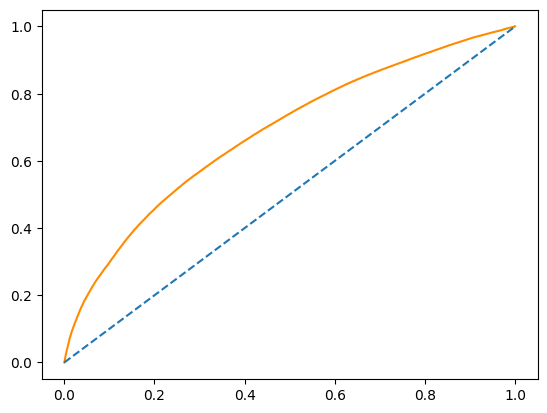

In [47]:
# Create predictions and store them in a variable
preds = clf_logistic.predict_proba(X_test)

# Print the accuracy score the model
print(clf_logistic.score(X_test, y_test))

# Plot the ROC curve of the probabilities of default
prob_default = preds[:, 1]
fallout, sensitivity, thresholds = roc_curve(y_test, prob_default)
plt.plot(fallout, sensitivity, color = 'darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()

# Compute the AUC and store it in a variable
auc = roc_auc_score(y_test, prob_default)

In [48]:
# Set the threshold for defaults to 0.5
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the confusion matrix
print(confusion_matrix(y_test, preds_df['loan_status']))

# Set the threshold for defaults to 0.4
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.4 else 0)

# Print the confusion matrix
print(confusion_matrix(y_test, preds_df['loan_status']))

[[   735 107195]
 [  1492 734759]]
[[     0 107930]
 [     0 736251]]


In [49]:
# Reassign the values of loan status based on the new threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Store the number of loan defaults from the prediction data
num_defaults = preds_df['loan_status'].value_counts()[1]

# Store the default recall from the classification report
default_recall = precision_recall_fscore_support(y_test, preds_df['loan_status'])[1][1]

avg_loan_amnt = loan_df_new['loan_amnt'].mean()

# Calculate the estimated impact of the new default recall rate
print(avg_loan_amnt * num_defaults * (1 - default_recall))

26014724.449390355


### Gradient Boosting

In [50]:
# Train a model
clf_gbt = xgb.XGBClassifier().fit(X_train, np.ravel(y_train))

# Predict with a model
gbt_preds = clf_gbt.predict_proba(X_test)

# Create dataframes of first five predictions, and first five true labels
preds_df = pd.DataFrame(gbt_preds[:,1][0:5], columns = ['prob_default'])
true_df = y_test.head()

# Concatenate and print the two data frames for comparison
print(pd.concat([true_df.reset_index(drop = True), preds_df], axis = 1))

   loan_status  prob_default
0          1.0      0.940450
1          0.0      0.763721
2          1.0      0.792815
3          1.0      0.884125
4          1.0      0.995743


Column Importance & Score

In [53]:
# Create and train the model on the training data
clf_gbt = xgb.XGBClassifier().fit(X_train,np.ravel(y_train))

# Print the column importances from the model
print(clf_gbt.get_booster().get_score(importance_type = 'weight'))
plt.show()

{'loan_int_rate': 2099.0, 'person_emp_length': 1167.0, 'person_income': 2403.0}


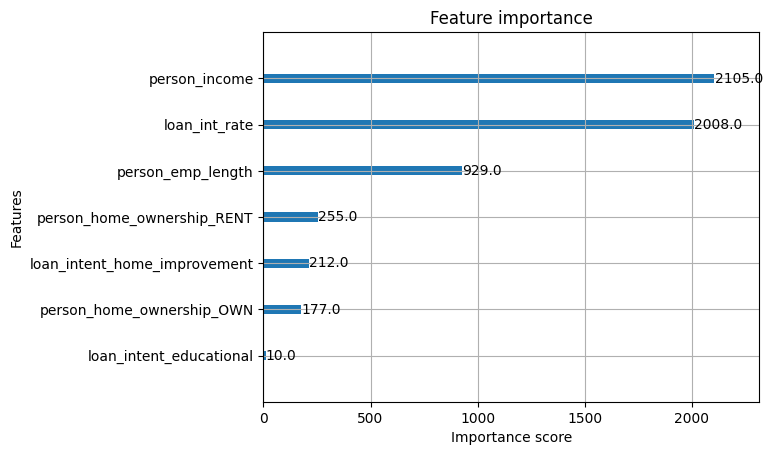

In [54]:
# Train a model on the X data with 2 columns
clf_gbt2 = xgb.XGBClassifier().fit(X1_train,np.ravel(y_train))

# Plot the column importance for this model
xgb.plot_importance(clf_gbt2, importance_type = 'weight')
plt.show()

In [56]:
# Predict the loan_status using each model
gbt_preds = clf_gbt.predict(X_test)
gbt2_preds = clf_gbt2.predict(X1_test)

# Print the classification report of the first model
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, gbt_preds, target_names=target_names))

# Print the classification report of the second model
print(classification_report(y_test, gbt2_preds, target_names=target_names))

              precision    recall  f1-score   support

 Non-Default       0.39      0.00      0.00    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.63      0.50      0.47    844181
weighted avg       0.81      0.87      0.81    844181

              precision    recall  f1-score   support

 Non-Default       0.35      0.00      0.00    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.61      0.50      0.47    844181
weighted avg       0.81      0.87      0.81    844181



Cross-validation

In [58]:
# Set the values for number of folds and stopping iterations
n_folds = 5
early_stopping = 10

# Create the DTrain matrix for XGBoost
DTrain = xgb.DMatrix(X_train, label = y_train)

# Define the parameters for the XGBoost model
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'seed': 123
}

# Create the data frame of cross validations
cv_df = xgb.cv(params, DTrain, num_boost_round = 5, nfold=n_folds,
            early_stopping_rounds=early_stopping)

# Print the cross validations data frame
print(cv_df)

   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.696702       0.000415       0.696103      0.001613
1        0.698879       0.000957       0.698184      0.001979
2        0.703004       0.001303       0.702243      0.002523
3        0.705297       0.000866       0.704519      0.001750
4        0.706529       0.000475       0.705764      0.001413


In [73]:

# Create the DTrain matrix for XGBoost
DTrain = xgb.DMatrix(X_train, label = y_train)

# Define the parameters for the XGBoost model
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'seed': 123
}

# Create the data frame of cross validations
cv_results_big = xgb.cv(params, DTrain, num_boost_round = 600, nfold=10,
            shuffle = True)

# Print the cross validations data frame
print(cv_df)

   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.696702       0.000415       0.696103      0.001613
1        0.698879       0.000957       0.698184      0.001979
2        0.703004       0.001303       0.702243      0.002523
3        0.705297       0.000866       0.704519      0.001750
4        0.706529       0.000475       0.705764      0.001413


   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.697171       0.000407       0.696898      0.002849
1        0.699170       0.000786       0.698597      0.002680
2        0.703790       0.001111       0.703145      0.002762
3        0.705772       0.000777       0.705059      0.002865
4        0.707358       0.000613       0.706586      0.002969
0.72


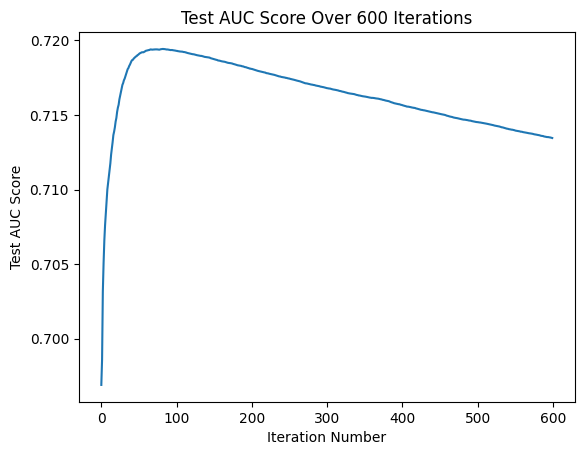

In [74]:
# Print the first five rows of the CV results data frame
print(cv_results_big.head(5))

# Calculate the mean of the test AUC scores
print(np.mean(cv_results_big['test-auc-mean']).round(2))

# Plot the test AUC scores for each iteration
plt.plot(cv_results_big['test-auc-mean'])
plt.title('Test AUC Score Over 600 Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Test AUC Score')
plt.show()

In [75]:
# Create a gradient boosted tree model using two hyperparameters
gbt = xgb.XGBClassifier(learning_rate = 0.1, max_depth = 7)

# Calculate the cross validation scores for 4 folds
cv_scores = cross_val_score(gbt, X_train, np.ravel(y_train), cv = 4)

# Print the cross validation scores
print(cv_scores)

# Print the average accuracy and standard deviation of the scores
print("Average accuracy: %0.2f (+/- %0.2f)" % (cv_scores.mean(),
                                              cv_scores.std() * 2))

[0.87171792 0.87171792 0.87171436 0.87170488]
Average accuracy: 0.87 (+/- 0.00)


Undersampling Non Defaults

In [76]:
X_y_train = pd.concat([X_train.reset_index(drop = True),
                       y_train.reset_index(drop = True)], axis = 1)
count_nondefault, count_default = X_y_train['loan_status'].value_counts()


# Create data sets for defaults and non-defaults
nondefaults = X_y_train[X_y_train['loan_status'] == 0]
defaults = X_y_train[X_y_train['loan_status'] == 1]

# Undersample the non-defaults
nondefaults_under = nondefaults.sample(count_default)

# Concatenate the undersampled nondefaults with defaults
X_y_train_under = pd.concat([nondefaults_under.reset_index(drop = True),
                             defaults.reset_index(drop = True)], axis = 0)

# Print the value counts for loan status
print(X_y_train_under['loan_status'].value_counts())

loan_status
1.0    1103822
0.0     162448
Name: count, dtype: int64


In [77]:
# Check the classification reports
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, gbt_preds, target_names=target_names))
print(classification_report(y_test, gbt2_preds, target_names=target_names))

              precision    recall  f1-score   support

 Non-Default       0.39      0.00      0.00    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.63      0.50      0.47    844181
weighted avg       0.81      0.87      0.81    844181

              precision    recall  f1-score   support

 Non-Default       0.35      0.00      0.00    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.61      0.50      0.47    844181
weighted avg       0.81      0.87      0.81    844181



In [78]:
# Print the confusion matrix for both old and new models
print(confusion_matrix(y_test,gbt_preds))
print(confusion_matrix(y_test,gbt2_preds))

[[    22 107908]
 [    35 736216]]
[[    29 107901]
 [    54 736197]]


In [79]:
# Print and compare the AUC scores of the old and new models
print(roc_auc_score(y_test, gbt_preds))
print(roc_auc_score(y_test, gbt2_preds))

0.5000781488418705
0.5000976740594213
